## Libs Data

Total .py files: 35269
Empty files: 0
Min: [25, 34, 42, 42, 48, 50, 51, 51, 55, 55]
Max: [51578, 51389, 51338, 51260, 51258, 51236, 51205, 51133, 51128, 51117]


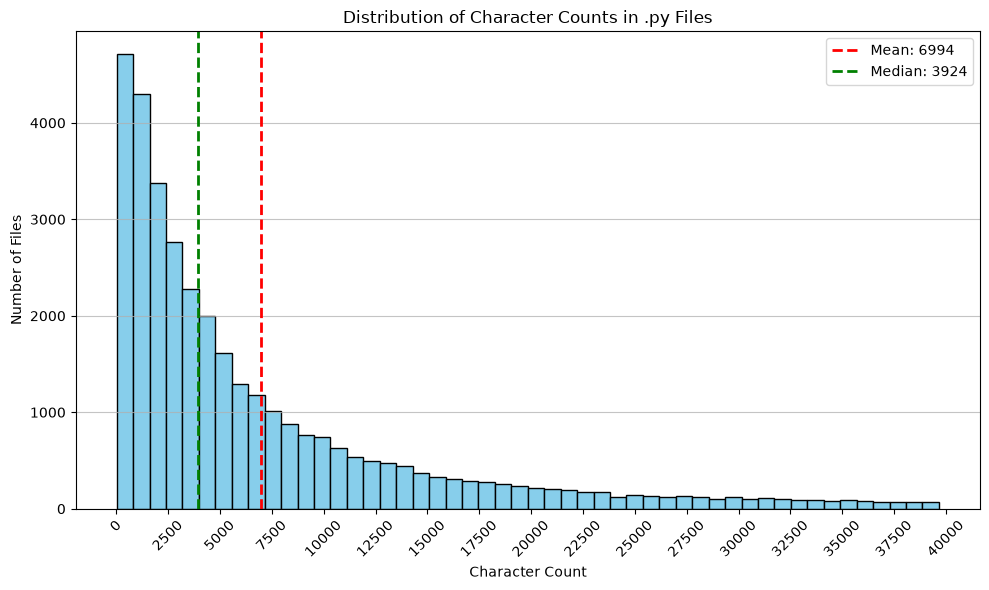

In [2]:
import os
import glob
import statistics
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


LIBS_DIR = "../data/raw/libs"

py_files = glob.glob(os.path.join(LIBS_DIR, "**", "*.py"), recursive=True)

char_counts = []
for file_path in py_files:
    try:
        with open(file_path, "r", encoding="utf-8") as f:
            content = f.read()
            char_counts.append(len(content))
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

if not char_counts:
    print("No .py files found")
    exit()
non_empty = [c for c in char_counts if c > 0]
if not non_empty:
    print("All .py files are empty.")
    exit()

non_empty.sort()
print(f"Total .py files: {len(char_counts)}")
print(f"Empty files: {len(char_counts) - len(non_empty)}")
print(f"Min: {non_empty[:10]}")
print(f"Max: {non_empty[-10:][::-1]}")
cutoff = int(len(non_empty) * 0.98) if len(non_empty) > 50 else len(non_empty)

plot_counts = non_empty[:cutoff]

plt.figure(figsize=(10, 6))
plt.hist(plot_counts, bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of Character Counts in .py Files")
plt.xlabel("Character Count")
plt.ylabel("Number of Files")
plt.grid(axis="y", alpha=0.75)

mean_val = statistics.mean(plot_counts)
median_val = statistics.median(plot_counts)
plt.axvline(
    mean_val,
    color="red",
    linestyle="dashed",
    linewidth=2,
    label=f"Mean: {mean_val:.0f}",
)
plt.axvline(
    median_val,
    color="green",
    linestyle="dashed",
    linewidth=2,
    label=f"Median: {median_val:.0f}",
)
plt.legend()

plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()

## Tokenized Finetune

In [ ]:
from datasets import load_from_disk

from src.utils.config_models import TokenizerConfig
from src.utils.tokenizer import get_finetune_tokenizer

CONFIG_PATH = "../configs.yaml"

config = TokenizerConfig.from_yaml(CONFIG_PATH)

tokenizer = get_finetune_tokenizer(config)

folder = "data/tokenized_finetune"
ds = load_from_disk(folder).to_pandas()


print(f"Dataset length: {len(ds)}")

print(f"Avg input_ids length: {ds['input_ids'].apply(len).mean()}")


print(f"P75: {ds['input_ids'].apply(len).quantile(0.75)}")
print(f"P90: {ds['input_ids'].apply(len).quantile(0.90)}")
print(f"P95: {ds['input_ids'].apply(len).quantile(0.95)}")

max_idx = ds['input_ids'].apply(len).idxmax()

max_input_ids = ds['input_ids'].iloc[max_idx]
max_text = tokenizer.decode(max_input_ids)

print(f"Index of longest sample: {max_idx}")
print(f"Length of longest sample: {len(max_input_ids)}")
print("-" * 20)
print("Content:")
print(max_text)